In [1]:
import numpy as np
import xarray as xr    
#import cartopy.crs as ccrs
#import matplotlib.ticker as mticker
#import matplotlib.pyplot as plt
#from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
# To interpolate NEMO data from Nico's mask files to the NEMO simulation grid 
from scipy.interpolate import griddata
import itertools
# To convert coordinates from lat, lon to polar stereo x,y 
from pyproj import Transformer
# KD Tree for nearest neighbours
from scipy.spatial import cKDTree
# To play a sound when at the end of the code you want to run 
import os
##os.system("printf '\a'")
import time
import glob

# Note, you don't have cartopy on laptop yet

In [2]:
import matplotlib.pyplot as plt
#import cartopy.crs as ccrs
# For plotting things on the polar stereographic grid with lat and lon coordinates 
#proj=ccrs.SouthPolarStereo(central_longitude=0.0)
#trans=ccrs.PlateCarree()

In [3]:
where_are_you_running = 'bettik'#, 'bettik', 'laptop'
# Set the filepaths for the data 
if where_are_you_running == 'bettik':
    filepath_base = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/'
elif where_are_you_running == 'laptop':
    filepath_base = '/Users/ockendeh/Documents/simpleNN_basal_melt/'
else:
    print('Help: I don\'t know where to look for files')

In [4]:
# Set all the filepaths that will be required 
# For loading in the cavity geometry and creating the T/S profiles mask 
# Domain file from Christoph
filepath_cfg = filepath_base + 'AIAI_data/Christoph/domain_cfg_eANT025.L121_notime.nc'
# Or from Nico?
#filepath_cfg = '../MASKS_PARAM/domain_cfg_eANT025.L121.nc'
# Domain file for the reduced cavity geometry 
filepath_cfg_reduced_cav = filepath_base + 'MASKS_PARAM/domain_cfg_eANT025.L121_REDUCED_CAV.nc'
# Basin numbers 
filepath_basin_nos = filepath_base + 'MASKS_PARAM/basin_raster_extrapolate_eANT025.nc'

# For calculating the T/S profiles, you need the NEMO output data 
filepath_Christoph = filepath_base + 'AIAI_data/Christoph/'

# The output nc files include
# A geometry file with the masks of the different types of cell and the basins 
filepath_mask = filepath_base +  'AIAI_data/Christoph/geometric_masks.nc'
# A geometry file with the required variables for the NN 
filepath_geomvars = filepath_base + 'AIAI_data/Christoph/geom_vars.nc'

# The data files to be processed 
filepaths_so = glob.glob(filepath_Christoph + 'so-eANT025.L121-isf94-1m_*.nc')
filepaths_fwfisf = glob.glob(filepath_Christoph + 'fwfisf-eANT025.L121-isf94-1m_*.nc')
filepaths_thetao = glob.glob(filepath_Christoph + 'thetao-eANT025.L121-isf94-1m_*.nc')

# The output file path for the T,S, melt files 
filepaths_TSmelt = filepath_Christoph + 'TSmelt_v2'

# 1) Create masks for this geometry 

- The first step to do is to extract the masks of the regions where there are different cell types (ocean, open cavity, closed cavity, and grounded ice), and create a mask of the region where the T/S profiles will be taken.

- **NOTE** It would be better to do the ice-shelf merge in this step if it is required...
Currently it is happening when the mask is applied in step 2, but it would be cleaner to have it in the mask producing step... 

- It is also important to calculate the relevant geometric variables for the Neural Network (slope, distances, bathymetry, ice-shelf draft).

In [5]:
# Load in the basin numbers file 
ds0=xr.open_dataset(filepath_basin_nos)
# Load in the domain geometry files 
dsREF=xr.open_dataset(filepath_cfg)
dsREDCAV=xr.open_dataset(filepath_cfg_reduced_cav)
if 'time_counter' in list(dsREF.dims):
    print('Squeezing the time_counter level in the cfg file')
    dsREF = dsREF.squeeze('time_counter')
dsREDCAV = dsREDCAV.squeeze('time_counter')

In [6]:
# Create masks for the ocean, closed cavities, open cavities, grounded ice 
ocean               = xr.where(((dsREF.top_level>0.5)&(dsREF.top_level<1.5)),1,0)
ocean_nan           = xr.where(((dsREF.top_level>0.5)&(dsREF.top_level<1.5)),1,np.nan)
all_cavities        = xr.where((dsREF.top_level>1.5),1,0)
all_cavities_nan    = xr.where((dsREF.top_level>1.5),1,np.nan)
closed_cavities     = xr.where(((dsREF.top_level>1.5)&(dsREDCAV.top_level<0.5)),1,0)
closed_cavities_nan = xr.where(((dsREF.top_level>1.5)&(dsREDCAV.top_level<0.5)),1,np.nan)
open_cavities       = xr.where((dsREDCAV.top_level>1.5),1,0)
open_cavities_nan   = xr.where((dsREDCAV.top_level>1.5),1,np.nan)
open_cav_ocean      = xr.where((ocean > 0.5),1, 0) + xr.where((open_cavities > 0.5), 1, 0)
open_cav_ocean_nan  = xr.where((open_cav_ocean == 1), 1, np.nan)
grounded_ice        = xr.where((ocean+all_cavities) == 0, 1,0)
grounded_ice_nan    = xr.where((ocean+all_cavities) == 0, 1,np.nan)
# Create the field for the basin numbers 
basins_NEMO         = ds0.basin
# Extract other useful paramaters
areas = dsREDCAV.e1t*dsREDCAV.e2t
bathymetry = dsREF.bathy_metry
isf_draft = dsREF.isf_draft

In [7]:
# Create files of distances and slopes
# Create a pyproj transform to go from lat lon to polar stereo
transformer = Transformer.from_crs("epsg:4326","epsg:3031")

# Create a list of all the points in closed ice shelves 
CC_lat, CC_lon = dsREF.nav_lat.data[closed_cavities == 1], dsREF.nav_lon.data[closed_cavities == 1]
CC_x, CC_y = transformer.transform(CC_lat, CC_lon)
points_CC = np.array(list(zip(CC_x, CC_y)))
# Create a list of all the grounded ice points
GL_lat, GL_lon = dsREF.nav_lat.data[grounded_ice == 1], dsREF.nav_lon.data[grounded_ice == 1]
GL_x, GL_y = transformer.transform(GL_lat, GL_lon)
points_GL = np.array(list(zip(GL_x, GL_y)))
# Create a list of all the open ocean points 
OO_lat, OO_lon = dsREF.nav_lat.data[ocean == 1], dsREF.nav_lon.data[ocean == 1]
OO_x, OO_y = transformer.transform(OO_lat, OO_lon)
points_OO = np.array(list(zip(OO_x, OO_y)))
# Create a list of all the open ocean cavity points
OC_lat, OC_lon = dsREF.nav_lat.data[open_cav_ocean == 1], dsREF.nav_lon.data[open_cav_ocean == 1]
OC_x, OC_y = transformer.transform(OC_lat, OC_lon)
points_OC = np.array(list(zip(OC_x, OC_y)))

# Create the cKD Tree for the grounding line 
tree = cKDTree(points_GL)
# Query the cKD Tree for the closed cavity points 
dist, index = tree.query(points_CC, k = 1)
distances_GL = np.ones(dsREF.nav_lat.data.shape)*np.nan
distances_GL[closed_cavities == 1] = dist

# Create the cKD Tree for the open ocean
tree = cKDTree(points_OO)
# Query the cKD Tree for the closed cavity points 
dist, index = tree.query(points_CC, k = 1)
distances_OO = np.ones(dsREF.nav_lat.data.shape)*np.nan
distances_OO[closed_cavities == 1] = dist

# Create the cKD Tree for the open ocean and cavities
tree = cKDTree(points_OC)
# Query the cKD Tree for the closed cavity points 
dist, index = tree.query(points_CC, k = 1)
distances_OC = np.ones(dsREF.nav_lat.data.shape)*np.nan
distances_OC[closed_cavities == 1] = dist

In [8]:
#print(len(np.unique(index)))
nearest_lats = np.ones(len(np.unique(index)))
nearest_lons = np.ones(len(np.unique(index)))
for i in range(len(np.unique(index))):
    nearest_lats[i], nearest_lons[i] = dsREF.nav_lat.values[open_cav_ocean == 1][np.unique(index)[i]], \
                                       dsREF.nav_lon.values[open_cav_ocean == 1][np.unique(index)[i]]
    print(i+1, 'out of', len(np.unique(index)), 'Coordinates calculated', end = '\r')
for i in range(len(nearest_lats)):
    if i == 0:
        mask = (dsREF.nav_lat == nearest_lats[i]) & (dsREF.nav_lon == nearest_lons[i])
        print('')
    else:
        mask_this_point = (dsREF.nav_lat == nearest_lats[i]) & (dsREF.nav_lon == nearest_lons[i])
        mask = mask + mask_this_point
    print(i+1, 'out of', len(np.unique(index)), 'Added to mask', end = '\r')
mask_TS_profiles = mask
mask_TS_profiles_nan = xr.where(mask_TS_profiles == 1, 1, np.nan)

2230 out of 2230 Coordinates calculated


In [9]:
# In order to calculate the slopes we need the distance between points, 
# and because the points are on the NEMO lat-lon grid we need to convert them to polar stereo the calculate the distances 
# Create a pyproj transformer to transform onto polar stereo
lat, lon = dsREF.nav_lat.data, dsREF.nav_lon.data
grid_x, grid_y = transformer.transform(lat, lon)
# Use the np.roll function to move the data slightly 
shifted_x_p0 = (grid_x - np.roll(grid_x, shift = 1, axis = 0))
shifted_x_m0 = (grid_x - np.roll(grid_x, shift = -1, axis = 0))
shifted_x_p1 = (grid_x - np.roll(grid_x, shift = 1, axis = 1))
shifted_x_m1 = (grid_x - np.roll(grid_x, shift = -1, axis = 1))
shifted_y_p0 = (grid_y - np.roll(grid_y, shift = 1, axis = 0))
shifted_y_m0 = (grid_y - np.roll(grid_y, shift = -1, axis = 0))
shifted_y_p1 = (grid_y - np.roll(grid_y, shift = 1, axis = 1))
shifted_y_m1 = (grid_y - np.roll(grid_y, shift = -1, axis = 1))
# Because you need to calculate the hypotenuse distance you need x and y for both directions of shift 
shifted_p_lon = np.sqrt(shifted_x_p0**2 + shifted_y_p0**2) # lon
shifted_m_lon = np.sqrt(shifted_x_m0**2 + shifted_y_m0**2) # lon 
shifted_p_lat = np.sqrt(shifted_x_p1**2 + shifted_y_p1**2) # lat
shifted_m_lat = np.sqrt(shifted_x_m1**2 + shifted_y_m1**2) # lat

In [10]:
interface = isf_draft*all_cavities_nan
interface_p_lon = ( + interface - np.roll(interface, shift = 1, axis = 0))/dsREF.e2t
interface_m_lon = (- interface + np.roll(interface, shift = -1, axis = 0))/dsREF.e2t
interface_p_lat = (+ interface - np.roll(interface, shift = 1, axis = 1))/dsREF.e1t
interface_m_lat = (- interface + np.roll(interface, shift = -1, axis = 1))/dsREF.e1t
bathymetry = bathymetry*all_cavities_nan
bathymetry_p_lon = ( + bathymetry - np.roll(bathymetry, shift = 1, axis = 0))/dsREF.e2t
bathymetry_m_lon = (- bathymetry + np.roll(bathymetry, shift = -1, axis = 0))/dsREF.e2t
bathymetry_p_lat = (+ bathymetry - np.roll(bathymetry, shift = 1, axis = 1))/dsREF.e1t
bathymetry_m_lat = (- bathymetry + np.roll(bathymetry, shift = -1, axis = 1))/dsREF.e1t
# Take the mean to get the actual local slope (and account for bendy points)
slope_isdraft_lon = np.nansum((interface_p_lon,interface_m_lon), axis = 0)/2
slope_isdraft_lat = np.nansum((interface_p_lat,interface_m_lat), axis = 0)/2
slope_bathy_lon = np.nansum((bathymetry_p_lon,bathymetry_m_lon), axis = 0)/2
slope_bathy_lat = np.nansum((bathymetry_p_lat,bathymetry_m_lat), axis = 0)/2
print('Local meridional and zonal slopes')

Local meridional and zonal slopes


In [11]:
print('If you have calculated the slopes properly, then there shouldn\'t be any nan values')
print('The following numbers should all be 0')
print(np.sum(np.isnan(slope_isdraft_lon)), np.sum(np.isnan(slope_isdraft_lat)), np.sum(np.isnan(slope_bathy_lon)), \
      np.sum(np.isnan(slope_bathy_lat)))

If you have calculated the slopes properly, then there shouldn't be any nan values
The following numbers should all be 0
0 0 0 0


In [12]:
# To calculate the rotated slopes then we need to look at things on a basin by basin basisd
direction_to_front = np.ones(dsREF.nav_lat.data.shape) * np.nan
no_cav_basins = []
#basin_no = 1
for jj in range(len(np.unique(basins_NEMO))):
    basin_no = jj+1
    mask_basin = xr.where(basins_NEMO == basin_no, 1, np.nan)
    x_basin = CC_x[basins_NEMO.values[closed_cavities_nan == 1] == basin_no]
    y_basin = CC_y[basins_NEMO.values[closed_cavities_nan == 1] == basin_no]
    if len(x_basin)>0:
        mean_x_basin = np.mean(x_basin)
        mean_y_basin = np.mean(y_basin)
        nearest_points_i = index[basins_NEMO.values[closed_cavities_nan == 1] == basin_no]
        nearest_x_i = np.ones(len(np.unique(nearest_points_i)))
        nearest_y_i = np.ones(len(np.unique(nearest_points_i)))
        for i in range(len(np.unique(nearest_points_i))):
            nearest_x_i[i], nearest_y_i[i] = OC_x[np.unique(nearest_points_i)[i]], \
                                                   OC_y[np.unique(nearest_points_i)[i]]
        mean_x_i = np.mean(nearest_x_i)
        mean_y_i = np.mean(nearest_y_i)
        direction = np.arctan2(mean_x_basin - mean_x_i, mean_y_basin - mean_y_i)
    else:
        direction = np.nan
        no_cav_basins.append(basin_no)
    #print(jj,len(x_basin), len(nearest_points_i),direction)
    direction_to_front[mask_basin == 1] = np.ones(int(np.nansum(mask_basin.values))) * direction
print('No closed cavities in the following basins:')
print(no_cav_basins)

No closed cavities in the following basins:
[5, 10, 30, 33, 39, 43, 48, 53, 54, 96, 106, 114, 123, 131]


In [13]:
# Then rotate the calculated slopes to have the slope towards the ice front and the slope across the ice front 
slope_isdraft_hypot = np.sqrt(slope_isdraft_lon **2 + slope_isdraft_lat **2)
angle_isdraft = np.arctan2(slope_isdraft_lon,slope_isdraft_lat)- direction_to_front
slope_is_across_front = slope_isdraft_hypot * np.sin(angle_isdraft)
slope_is_towards_front = slope_isdraft_hypot * np.cos(angle_isdraft)
slope_bathy_hypot = np.sqrt(slope_bathy_lon **2 + slope_bathy_lat **2)
angle_bathy = np.arctan2(slope_bathy_lon,slope_bathy_lat)- direction_to_front
slope_ba_across_front = slope_bathy_hypot * np.sin(angle_bathy)
slope_ba_towards_front = slope_bathy_hypot * np.cos(angle_bathy)
print('Rotated slopes')

Rotated slopes


In [14]:
print('If you have calculated the slopes properly, then there shouldn\'t be any nan values')
print('The following numbers should all be 0')
print(np.sum(np.isnan(slope_is_across_front[closed_cavities == 1])), np.sum(np.isnan(slope_is_towards_front[closed_cavities == 1])), 
      np.sum(np.isnan(slope_ba_across_front[closed_cavities == 1])), np.sum(np.isnan(slope_ba_towards_front[closed_cavities == 1])))

If you have calculated the slopes properly, then there shouldn't be any nan values
The following numbers should all be 0
0 0 0 0


In [15]:
# Save one file for the 
ds = xr.Dataset(
        data_vars=dict(
            ocean_only              = (["y", "x"], ocean.data),
            ocean_only_nan          = (["y", "x"], ocean_nan.data),
            all_cavities            = (["y", "x"], all_cavities.data),
            all_cavities_nan        = (["y", "x"], all_cavities_nan.data),
            closed_cavities         = (["y", "x"], closed_cavities.data),
            closed_cavities_nan     = (["y", "x"], closed_cavities_nan.data),
            open_cavities           = (["y", "x"], open_cavities.data),
            open_cavities_nan       = (["y", "x"], open_cavities_nan.data),
            ocean_open_cavities     = (["y", "x"], open_cav_ocean.data),
            ocean_open_cavities_nan = (["y", "x"], open_cav_ocean.data),
            grounded_ice            = (["y", "x"], grounded_ice.data),
            grounded_ice_nan        = (["y", "x"], grounded_ice_nan.data),    
            basins_NEMO             = (["y", "x"], basins_NEMO.data),
            mask_TS_profiles        = (["y", "x"], mask_TS_profiles.data),
            mask_TS_profiles_nan    = (["y", "x"], mask_TS_profiles_nan.data),
            ),
        coords=dict(
            lon=(("y", "x"), dsREF.nav_lon.data),
            lat=(("y", "x"), dsREF.nav_lat.data),    ),
        attrs=dict(description="Masks for grounded ice, floating ice and open ocean", 
                   simulation_run = 'Christoph_CFG'),
    )
ds.to_netcdf(filepath_mask)
print('You have saved the following file')
print(filepath_mask)

You have saved the following file
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/geometric_masks.nc


In [16]:
# Save one file for the 
ds = xr.Dataset(
        data_vars=dict(
            ocean_only              = (["y_grid_T", "x_grid_T"], ocean.data),
            ocean_only_nan          = (["y_grid_T", "x_grid_T"], ocean_nan.data),
            all_cavities            = (["y_grid_T", "x_grid_T"], all_cavities.data),
            all_cavities_nan        = (["y_grid_T", "x_grid_T"], all_cavities_nan.data),
            closed_cavities         = (["y_grid_T", "x_grid_T"], closed_cavities.data),
            closed_cavities_nan     = (["y_grid_T", "x_grid_T"], closed_cavities_nan.data),
            open_cavities           = (["y_grid_T", "x_grid_T"], open_cavities.data),
            open_cavities_nan       = (["y_grid_T", "x_grid_T"], open_cavities_nan.data),
            ocean_open_cavities     = (["y_grid_T", "x_grid_T"], open_cav_ocean.data),
            ocean_open_cavities_nan = (["y_grid_T", "x_grid_T"], open_cav_ocean.data),
            grounded_ice            = (["y_grid_T", "x_grid_T"], grounded_ice.data),
            grounded_ice_nan        = (["y_grid_T", "x_grid_T"], grounded_ice_nan.data),    
            basins_NEMO             = (["y_grid_T", "x_grid_T"], basins_NEMO.data),
            mask_TS_profiles        = (["y_grid_T", "x_grid_T"], mask_TS_profiles.data),
            mask_TS_profiles_nan    = (["y_grid_T", "x_grid_T"], mask_TS_profiles_nan.data),
            ),
        coords=dict(
            lon=(("y_grid_T", "x_grid_T"), dsREF.nav_lon.data),
            lat=(("y_grid_T", "x_grid_T"), dsREF.nav_lat.data),    ),
        attrs=dict(description="Masks for grounded ice, floating ice and open ocean", 
                   simulation_run = 'Christoph_CFG'),
    )
ds.to_netcdf(filepath_mask)
print('You have saved the following file')
print(filepath_mask)

You have saved the following file
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/geometric_masks.nc


In [17]:
# And then save these to file 
ds = xr.Dataset(
            data_vars=dict(
                areas                  = (["y", "x"], areas.data),
                bathymetry             = (["y", "x"], bathymetry.data),
                isf_draft              = (["y", "x"], isf_draft.data),
                distances_GL           = (["y", "x"], distances_GL.data),
                distances_OO           = (["y", "x"], distances_OO.data),
                distances_OC           = (["y", "x"], distances_OC.data),
                slope_isdraft_lon      = (["y", "x"], slope_isdraft_lon.data),
                slope_isdraft_lat      = (["y", "x"], slope_isdraft_lat.data),
                slope_bathy_lon        = (["y", "x"], slope_bathy_lon.data),
                slope_bathy_lat        = (["y", "x"], slope_bathy_lat.data),
                slope_is_across_front  = (["y", "x"], slope_is_across_front.data),
                slope_is_towards_front = (["y", "x"], slope_is_towards_front.data),
                slope_ba_across_front  = (["y", "x"], slope_ba_across_front.data),
                slope_ba_towards_front = (["y", "x"], slope_ba_towards_front.data),
                ),
            coords=dict(
                lon=(("y", "x"), dsREF.nav_lon.data),
                lat=(("y", "x"), dsREF.nav_lat.data),    ),
            attrs=dict(description = "Required geometry variables for this geometry", 
                       simulation_run = 'Christoph_CFG'),
                )
ds.to_netcdf(filepath_geomvars)
print('You have saved the following file')
print(filepath_geomvars)

You have saved the following file
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/geom_vars.nc


# 2) Extract the temperature and salinity profiles for each ice shelf for each month/year

In [181]:
def load_geom_files(filepath_geomvars, filepath_mask, join_ice_shelves = False):
    geoms = xr.open_dataset(filepath_geomvars)
    masks = xr.open_dataset(filepath_mask)
    print('You have loaded:', filepath_geomvars)
    print('You have laoded:', filepath_mask)
    bN_00 = masks.basins_NEMO
    # Some ice shelves which should potentially be joined together into one bigger ice shelf
    if join_ice_shelves == True:
        # Dotson and Crosson?
        #basins_NEMO[basins_NEMO == 101] = 129
        # Abbot Ice Shelf
        bN_01 = xr.where(bN_00 == 109, 143, bN_00)
        # George VI
        bN_02 = xr.where(bN_01 == 112, 125, bN_01)
        # Lambert 
        basins_merged = xr.where(bN_02 == 20, 103, bN_02)
        print('Ice shelves joined, as requested')
    else:
        basins_merged = bN_00    
    return masks, basins_merged, geoms

def load_TSmelt_files(filepaths_so, filepaths_thetao, filepaths_fwfisf, year):
    for i in range(len(filepaths_so)):
            if filepaths_so[i].split(os.sep)[-1].split('.nc')[0].split('_')[-1] == str(year):
                # Import the chosen file
                so = xr.open_dataset(filepaths_so[i])
                print('You have loaded:', filepaths_so[i])
            if filepaths_thetao[i].split(os.sep)[-1].split('.nc')[0].split('_')[-1] == str(year):
                thetao = xr.open_dataset(filepaths_thetao[i])
                print('You have loaded:', filepaths_thetao[i])
            if filepaths_fwfisf[i].split(os.sep)[-1].split('.nc')[0].split('_')[-1] == str(year):
                fwfisf = xr.open_dataset(filepaths_fwfisf[i])
                print('You have loaded:', filepaths_fwfisf[i])
    return so, thetao, fwfisf
    
def extractTSmelt(masks, basins_merged, geoms, so, thetao, fwfisf, filepaths_TSmelt, year, month):
    # To get the x,y,z, grid for a particular time slice 
    so_time = so.drop_vars('time_centered').so.isel(time_counter = month).drop_vars('time_counter')
    thetao_time = thetao.drop_vars('time_centered').thetao.isel(time_counter = month).drop_vars('time_counter')
    fwfisf_time = fwfisf.drop_vars('time_centered').fwfisf.isel(time_counter = month).drop_vars('time_counter')
    thetao_time = xr.where(thetao_time == 0, np.nan, thetao_time)
    so_time = xr.where(so_time == 0, np.nan, so_time)
    # Note changed drop to drop_vars to work better with this version of xarray
    # Then need to loop over each basin to extract the temperature profiles in the correct region 
    # Create arrays for the profiles to be put into 
    profiles_T = xr.where(so_time == 0,0,0)
    profiles_S = xr.where(so_time == 0,0,0)
    for jj in range(len(np.unique(masks.basins_NEMO))):
        print(jj+1, 'out of', len(np.unique(masks.basins_NEMO)), end = '\r')
        basin_no = jj+1
        mask_TS_basin = xr.where((basins_merged == basin_no) & (masks.mask_TS_profiles == 1), 1, np.nan) == 1
        if np.sum(mask_TS_basin) != 0:
            extract = thetao_time.where(mask_TS_basin == 1).stack(all_dims=['y_grid_T', 'x_grid_T']).dropna('all_dims')
            extract_nan = xr.where(extract == 0,np.nan, extract)
            mean_profile = extract_nan.mean(dim = 'all_dims', skipna = True)
            filled_profileT = mean_profile.interpolate_na(dim = 'deptht').ffill(dim = 'deptht').bfill(dim = 'deptht')
            extract = so_time.where(mask_TS_basin == 1).stack(all_dims=['y_grid_T', 'x_grid_T']).dropna('all_dims')
            extract_nan = xr.where(extract == 0,np.nan, extract)
            mean_profile = extract_nan.mean(dim = 'all_dims', skipna = True)
            filled_profileS = mean_profile.interpolate_na(dim = 'deptht').ffill(dim = 'deptht').bfill(dim = 'deptht')
            # Expand xarrrays to add them all to an x,y,z grid which the depth mask can then be applied to 
            profileT_expanded = filled_profileT.expand_dims({"y_grid_T": so_time.y_grid_T, "x_grid_T": so_time.x_grid_T})
            profileT_basin = profileT_expanded*(basins_merged == basin_no)
            profiles_T = profiles_T + profileT_basin
            profileS_expanded = filled_profileS.expand_dims({"y_grid_T": so_time.y_grid_T, "x_grid_T": so_time.x_grid_T})
            profileS_basin = profileS_expanded*(basins_merged == basin_no)
            profiles_S = profiles_S + profileS_basin
    draft = geoms.isf_draft.rename({'x': 'x_grid_T', 'y':'y_grid_T'})#*masks.closed_cavities_nan
    interp_S = profiles_S.drop_vars(['nav_lat_grid_T','nav_lon_grid_T','y_grid_T', \
                          'x_grid_T']).sel(deptht = draft, method = 'nearest')*masks.closed_cavities_nan
    interp_T = profiles_T.drop_vars(['nav_lat_grid_T','nav_lon_grid_T','y_grid_T', \
                          'x_grid_T']).sel(deptht = draft, method = 'nearest')*masks.closed_cavities_nan
    #ds = xr.Dataset(
    #            data_vars=dict(
    #                temperature_prop    = (["y", "x"], interp_S.data),
    #                salinity_prop       = (["y", "x"], interp_T.data),
    #                melt_ice_per_yr     = (["y", "x"], (fwfisf_time.values*masks.closed_cavities_nan).data),
    #                ),
    #            coords=dict(
    #                lon=(("y", "x"), interp_S.lon.data),
    #                lat=(("y", "x"), interp_S.lat.data),    ),
    #            attrs=dict(description = "Pointwise T, S, and melt", 
    #                       simulation_run = 'Christoph_CFG',
    #                       year = year,
    #                       month = month)
    #                )
    #fp_TSmelt = filepaths_TSmelt + '_y' + str(year) + '_m' + str(month).zfill(2) +'.nc'
    #ds.to_netcdf(fp_TSmelt)
    #print('You have saved the following file')
    #print(fp_TSmelt)
    return interp_T, interp_S

def extractTSmelt_v2(masks, basins_merged, geoms, so, thetao, fwfisf, filepaths_TSmelt, year, month):
    # To get the x,y,z, grid for a particular time slice 
    so_time = so.drop_vars('time_centered').so.isel(time_counter = month).drop_vars('time_counter')
    thetao_time = thetao.drop_vars('time_centered').thetao.isel(time_counter = month).drop_vars('time_counter')
    fwfisf_time = fwfisf.drop_vars('time_centered').fwfisf.isel(time_counter = month).drop_vars('time_counter')
    thetao_time = xr.where(thetao_time == 0, np.nan, thetao_time)
    so_time = xr.where(so_time == 0, np.nan, so_time)
    # Calculate the basin numbers of any basin which contains closed cavities 
    basin_nos_temp = np.unique(basins_merged)
    count = np.zeros(len(basin_nos_temp))
    for i in range(len(basin_nos_temp)):
        count[i] = np.sum((basins_merged*masks.closed_cavities_nan) == basin_nos_temp[i])
    mask_keep_nos = count != 0
    basin_nos = basin_nos_temp[mask_keep_nos]
    # Create empty arrays for the propagated temperature and salinity (on NEMO grid)
    T_prop = np.ones(so.nav_lat_grid_T.data.shape)*np.nan
    S_prop = np.ones(so.nav_lat_grid_T.data.shape)*np.nan
    for kk in range(len(basin_nos)):
    #kk = 55
        basin_no = basin_nos[kk]
        mask_TS_basin = xr.where((basins_merged == basin_no) & (masks.mask_TS_profiles == 1), 1, np.nan) == 1
        real_profile = thetao_time.where(mask_TS_basin == 1).mean(dim = ['x_grid_T','y_grid_T'], skipna = True)
        T_profile = real_profile.interpolate_na(dim = 'deptht').ffill(dim = 'deptht').bfill(dim = 'deptht')
        real_profile = so_time.where(mask_TS_basin == 1).mean(dim = ['x_grid_T','y_grid_T'], skipna = True)
        S_profile = real_profile.interpolate_na(dim = 'deptht').ffill(dim = 'deptht').bfill(dim = 'deptht')
        mask_basin = basins_merged*masks.closed_cavities_nan == basin_no
        T_prop[mask_basin] = T_profile.sel(deptht = geoms.isf_draft.data[mask_basin], method = 'nearest')
        S_prop[mask_basin] = S_profile.sel(deptht = geoms.isf_draft.data[mask_basin], method = 'nearest')
        print('Currently processing:', year, month, ',', \
                  kk+1, 'out of', len(basin_nos), 'profiles processed', end = '\r')
    ds = xr.Dataset(
                data_vars=dict(
                    temperature_prop    = (["y", "x"], T_prop.data),
                    salinity_prop       = (["y", "x"], S_prop.data),
                    melt_ice_per_yr     = (["y", "x"], (fwfisf_time.values*masks.closed_cavities_nan).data),
                    ),
                coords=dict(
                    lon=(("y", "x"), so.nav_lon_grid_T.data),
                    lat=(("y", "x"), so.nav_lat_grid_T.data),    ),
                attrs=dict(description = "Pointwise T, S, and melt", 
                           simulation_run = 'Christoph_CFG',
                           year = year,
                           month = month)
                    )
    fp_TSmelt = filepaths_TSmelt + '_y' + str(year) + '_m' + str(month).zfill(2) +'.nc'
    ds.to_netcdf(fp_TSmelt)
    print('You have saved the following file')
    print(fp_TSmelt)

In [169]:
filepaths_TSmelt

'/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/TSmelt_v2'

In [175]:
glob.glob('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/TSmelt_v2*')

['/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/TSmelt_v2_y2025_m01.nc']

In [ ]:
%%time
masks, basins_merged, geoms = load_geom_files(filepath_geomvars, filepath_mask, join_ice_shelves = True)
year = 2024 
so, thetao, fwfisf = load_TSmelt_files(filepaths_so, filepaths_thetao, filepaths_fwfisf, year)
for i in range(12):
    extractTSmelt_v2(masks, basins_merged, geoms, so, thetao, fwfisf, filepaths_TSmelt, year, i)
#extractTSmelt_v2(masks, basins_merged, geoms, so, thetao, fwfisf, filepaths_TSmelt, year, 0)

You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/geom_vars.nc
You have laoded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/geometric_masks.nc
Ice shelves joined, as requested
You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/so-eANT025.L121-isf94-1m_2024.nc
You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/thetao-eANT025.L121-isf94-1m_2024.nc
You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/fwfisf-eANT025.L121-isf94-1m_2024.nc
You have saved the following file8 out of 138 profiles processed
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/TSmelt_v2_y2024_m00.nc
You have saved the following file8 out of 138 profiles processed
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/TSmelt_v2_y2024_m01.nc
You have saved the following file8 out of 138 profiles processed
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AI

/tmp/ipykernel_1841208/621551464.py:2: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


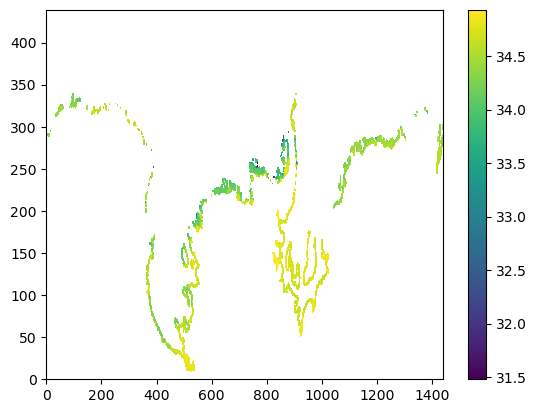

In [160]:
plt.pcolor(interp_S)
plt.colorbar()

In [60]:
mask_TS_basin

<xarray.DataArray (y_grid_T: 439, x_grid_T: 1440)>
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
    lon      (y_grid_T, x_grid_T) float32 73.0 73.25 73.5 ... 72.25 72.5 72.75
    lat      (y_grid_T, x_grid_T) float32 -84.2 -84.2 -84.2 ... -52.25 -52.25
Dimensions without coordinates: y_grid_T, x_grid_T

In [78]:
so_time = so.drop_vars('time_centered').so.isel(time_counter = month).drop_vars('time_counter')
thetao_time = thetao.drop_vars('time_centered').thetao.isel(time_counter = month).drop_vars('time_counter')
fwfisf_time = fwfisf.drop_vars('time_centered').fwfisf.isel(time_counter = month).drop_vars('time_counter')
thetao_time = xr.where(thetao_time == 0, np.nan, thetao_time)
so_time = xr.where(so_time == 0, np.nan, so_time)
# Note changed drop to drop_vars to work better with this version of xarray
# Then need to loop over each basin to extract the temperature profiles in the correct region 
# Create arrays for the profiles to be put into 
profiles_T = xr.where(so_time == 0,0,0)
profiles_S = xr.where(so_time == 0,0,0)
#for jj in range(len(np.unique(masks.basins_NEMO))):
jj = 2
print(jj+1, 'out of', len(np.unique(masks.basins_NEMO)), end = '\r')
basin_no = jj+1
mask_TS_basin = xr.where((basins_merged == basin_no) & (masks.mask_TS_profiles == 1), 1, np.nan) == 1
if np.sum(mask_TS_basin) != 0:
    extract = thetao_time.where(mask_TS_basin == 1).stack(all_dims=['y_grid_T', 'x_grid_T']).dropna('all_dims')
    extract_nan = xr.where(extract == 0,np.nan, extract)
    mean_profile = extract_nan.mean(dim = 'all_dims', skipna = True)
    filled_profileT = mean_profile.interpolate_na(dim = 'deptht').ffill(dim = 'deptht').bfill(dim = 'deptht')
    extract = so_time.where(mask_TS_basin == 1).stack(all_dims=['y_grid_T', 'x_grid_T']).dropna('all_dims')
    extract_nan = xr.where(extract == 0,np.nan, extract)
    mean_profile = extract_nan.mean(dim = 'all_dims', skipna = True)
    filled_profileS = mean_profile.interpolate_na(dim = 'deptht').ffill(dim = 'deptht').bfill(dim = 'deptht')

In [79]:
filled_profileS

<xarray.DataArray 'so' (deptht: 121)>
array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan], dtype=float32)
Coordinates:
  * deptht   (deptht) float32 0.4921 1.526 2.638 ... 5.698e+03 5.902e+03

In [48]:
thetao_time.where(mask_TS_basin == 1).stack(all_dims=['y_grid_T', 'x_grid_T'])

<xarray.DataArray 'thetao' (deptht: 121, all_dims: 632160)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * deptht          (deptht) float32 0.4921 1.526 2.638 ... 5.698e+03 5.902e+03
    nav_lat_grid_T  (all_dims) float32 -84.2 -84.2 -84.2 ... -52.25 -52.25
    nav_lon_grid_T  (all_dims) float32 73.0 73.25 73.5 ... 72.25 72.5 72.75
    lon             (all_dims) float32 73.0 73.25 73.5 ... 72.25 72.5 72.75
    lat             (all_dims) float32 -84.2 -84.2 -84.2 ... -52.25 -52.25
  * all_dims        (all_dims) object MultiIndex
  * y_grid_T        (all_dims) int64 0 0 0 0 0 0 0 ... 438 438 438 438 438 438
  * x_grid_T        (all_dims) int64 0 1 2 3 4 5 ... 1435 1436 1437 1438 1439

In [82]:
%%time
masks, basins_merged, geoms = load_geom_files(filepath_geomvars, filepath_mask, join_ice_shelves = True)
year = 2025 
so, thetao, fwfisf = load_TSmelt_files(filepaths_so, filepaths_thetao, filepaths_fwfisf, year)
#for i in range(12):
#    extractTSmelt(masks, basins_merged, geoms, so, thetao, fwfisf, filepaths_TSmelt, year, i)
#interp_T, interp_S = extractTSmelt(masks, basins_merged, geoms, so, thetao, fwfisf, filepaths_TSmelt, year, 1)
month = 0
so_time = so.drop_vars('time_centered').so.isel(time_counter = month).drop_vars('time_counter')
thetao_time = thetao.drop_vars('time_centered').thetao.isel(time_counter = month).drop_vars('time_counter')
fwfisf_time = fwfisf.drop_vars('time_centered').fwfisf.isel(time_counter = month).drop_vars('time_counter')
thetao_time = xr.where(thetao_time == 0, np.nan, thetao_time)
so_time = xr.where(so_time == 0, np.nan, so_time)
verbose = 1

You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/geom_vars.nc
You have laoded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/geometric_masks.nc
Ice shelves joined, as requested
You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/so-eANT025.L121-isf94-1m_2025.nc
You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/thetao-eANT025.L121-isf94-1m_2025.nc
You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/fwfisf-eANT025.L121-isf94-1m_2025.nc
CPU times: user 2.59 s, sys: 727 ms, total: 3.31 s
Wall time: 3.38 s


/tmp/ipykernel_1841208/621551464.py:2: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


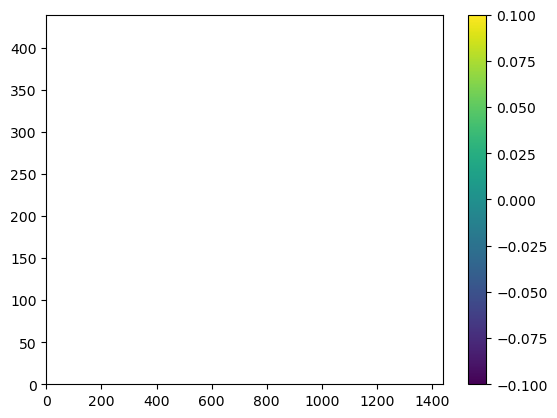

In [42]:
plt.pcolor(interp_S)
plt.colorbar()

In [21]:
masks = xr.open_dataset(filepath_mask)
ocean_open_cavities = masks.ocean_open_cavities.data
grounded_ice = masks.grounded_ice.data
ocean_only = masks.ocean_only.data
closed_cavities = masks.closed_cavities.data
masks.close()
basins_NEMO = basins_merged
# Calculate the basin numbers of any basin which contains closed cavities 
basin_nos_temp = np.unique(basins_NEMO)
count = np.zeros(len(basin_nos_temp))
for i in range(len(basin_nos_temp)):
    count[i] = np.sum((basins_NEMO*masks.closed_cavities_nan) == basin_nos_temp[i])
mask_keep_nos = count != 0
basin_nos = basin_nos_temp[mask_keep_nos]
# Calculate depth of ocean interface
mask_temp_values = xr.where(thetao_time > -200, 1,0)
mask_diff_temp = (mask_temp_values - mask_temp_values.shift(deptht=1))
positive = xr.where(mask_diff_temp == 1, 1, np.nan)
negative = xr.where(mask_diff_temp == -1, 1, np.nan)
# Create empty arrays for the propagated temperature and salinity (on NEMO grid)
T_prop = np.ones(so.nav_lat_grid_T.data.shape)*np.nan
S_prop = np.ones(so.nav_lat_grid_T.data.shape)*np.nan
# Create arrays for the temperature and salinity profiles
T_profiles = np.ndarray(len(basin_nos), dtype = np.ndarray) 
S_profiles = np.ndarray(len(basin_nos), dtype = np.ndarray) 

In [88]:
kk = 4
i = basin_nos[kk]
# Extract the closed cavity points which are in that basin
mask_basin = basins_NEMO*masks.closed_cavities_nan == i
x_b, y_b = transformer.transform(so.nav_lat_grid_T.data[mask_basin], so.nav_lon_grid_T.data[mask_basin])
points_basin = np.array(list(zip(x_b,y_b)))
# Query the cKDTree to calculate the distances to points within the basin
distance, index = tree.query(points_basin)
# Extract only the points that are adjacent to the closed cavity (by using the minimum distance) 
results = tree.query_ball_point(points_basin, r = np.min(distance)*np.sqrt(2))
# Extract indexes and create a list of the unique points adjacent to the closed cavity 
merged = np.unique(list(itertools.chain.from_iterable(results)))
chosen_x = OC_x[merged]
chosen_y = OC_y[merged]
chosen_x, chosen_y
points_chosen = np.array(list(zip(chosen_x, chosen_y)))
# Create a cKD Tree with the chosen points 
tree_i = cKDTree(points_chosen)
# Query the tree for the points within the closed cavity
distance, index = tree_i.query(points_basin)
distances_OC[mask_basin] = distance
chosen_lon = so.nav_lon_grid_T.data[ocean_open_cavities == 1][merged]
chosen_lat = so.nav_lat_grid_T.data[ocean_open_cavities == 1][merged]

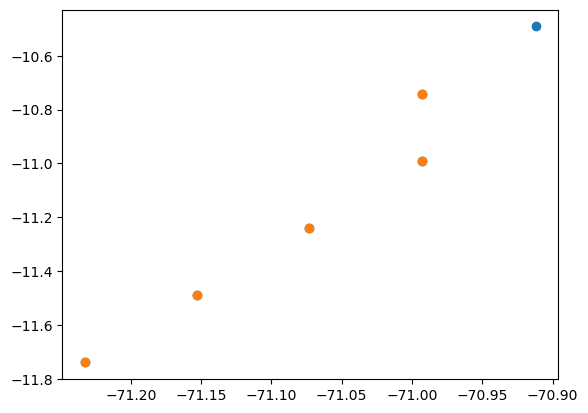

In [89]:
basin_no = i
mask_TS_basin = xr.where((basins_merged == basin_no) & (masks.mask_TS_profiles == 1), 1, np.nan) == 1
plt.scatter(chosen_lat, chosen_lon)
plt.scatter(so.nav_lat_grid_T.data[mask_TS_basin], so.nav_lon_grid_T.data[mask_TS_basin])

In [113]:
so_time = so.drop_vars('time_centered').so.isel(time_counter = month).drop_vars('time_counter')
thetao_time = thetao.drop_vars('time_centered').thetao.isel(time_counter = month).drop_vars('time_counter')
fwfisf_time = fwfisf.drop_vars('time_centered').fwfisf.isel(time_counter = month).drop_vars('time_counter')
thetao_time2 = xr.where(thetao_time == 0, np.nan, thetao_time)
so_time2 = xr.where(so_time == 0, np.nan, so_time)

In [154]:
%%time
basins_NEMO = basins_merged
# Calculate the basin numbers of any basin which contains closed cavities 
basin_nos_temp = np.unique(basins_NEMO)
count = np.zeros(len(basin_nos_temp))
for i in range(len(basin_nos_temp)):
    count[i] = np.sum((basins_NEMO*masks.closed_cavities_nan) == basin_nos_temp[i])
mask_keep_nos = count != 0
basin_nos = basin_nos_temp[mask_keep_nos]

# Create empty arrays for the propagated temperature and salinity (on NEMO grid)
T_prop = np.ones(so.nav_lat_grid_T.data.shape)*np.nan
S_prop = np.ones(so.nav_lat_grid_T.data.shape)*np.nan
for kk in range(len(basin_nos)):
#kk = 55
    basin_no = basin_nos[kk]
    mask_TS_basin = xr.where((basins_merged == basin_no) & (masks.mask_TS_profiles == 1), 1, np.nan) == 1
    real_profile = thetao_time2.where(mask_TS_basin == 1).mean(dim = ['x_grid_T','y_grid_T'], skipna = True)
    T_profile = real_profile.interpolate_na(dim = 'deptht').ffill(dim = 'deptht').bfill(dim = 'deptht')
    real_profile = so_time2.where(mask_TS_basin == 1).mean(dim = ['x_grid_T','y_grid_T'], skipna = True)
    S_profile = real_profile.interpolate_na(dim = 'deptht').ffill(dim = 'deptht').bfill(dim = 'deptht')
    mask_basin = basins_merged*masks.closed_cavities_nan == basin_no
    T_prop[mask_basin] = T_profile.sel(deptht = geoms.isf_draft.data[mask_basin], method = 'nearest')
    S_prop[mask_basin] = S_profile.sel(deptht = geoms.isf_draft.data[mask_basin], method = 'nearest')
    if verbose == 2:
        print('Creating and propagating profiles:', kk+1, 'out of', len(basin_nos), 'processed', end = '\r')
    if verbose == 1:
        print('Currently processing:', year, month, ',', \
              kk+1, 'out of', len(basin_nos), 'profiles processed', end = '\r')

CPU times: user 1min 17s, sys: 36.1 s, total: 1min 53s processed
Wall time: 1min 55s


/tmp/ipykernel_1841208/2922846825.py:2: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


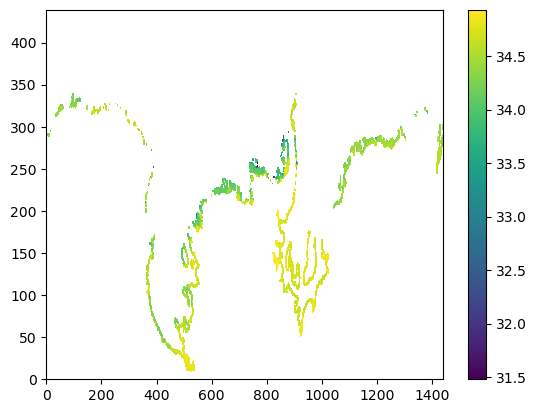

In [155]:
plt.pcolor(S_prop)
plt.colorbar()


In [152]:
T_profile.sel(deptht = geoms.isf_draft.data[mask_basin], method = 'nearest')

<xarray.DataArray 'thetao' (deptht: 104)>
array([-2.4736543, -2.4736543, -2.495733 , -2.495733 , -2.484947 ,
       -2.484947 , -2.484947 , -2.484947 , -2.484947 , -2.495733 ,
       -2.495733 , -2.4804745, -2.495733 , -2.495733 , -2.495733 ,
       -2.484947 , -2.484947 , -2.495733 , -2.495733 , -2.4804745,
       -2.4804745, -2.495733 , -2.4804745, -2.4804745, -2.4804745,
       -2.4804745, -2.4804745, -2.495733 , -2.4804745, -2.495733 ,
       -2.495733 , -2.495733 , -2.495733 , -2.4804745, -2.4804745,
       -2.4804745, -2.495733 , -2.4804745, -2.4804745, -2.4804745,
       -2.4804745, -2.495733 , -2.484947 , -2.4804745, -2.4804745,
       -2.4804745, -2.4804745, -2.4804745, -2.4804745, -2.4804745,
       -2.495733 , -2.4804745, -2.4804745, -2.4804745, -2.4804745,
       -2.495733 , -2.495733 , -2.495733 , -2.4804745, -2.4804745,
       -2.4804745, -2.4804745, -2.4804745, -2.4804745, -2.4804745,
       -2.4804745, -2.4804745, -2.4804745, -2.495733 , -2.495733 ,
       -2.495733 , -2.4804745, -2.4804745, -2.4804745, -2.4804745,
       -2.4804745, -2.4804745, -2.4804745, -2.4804745, -2.495733 ,
       -2.484947 , -2.495733 , -2.495733 , -2.4804745, -2.4804745,
       -2.4804745, -2.4804745, -2.4804745, -2.4804745, -2.4804745,
       -2.4804745, -2.495733 , -2.484947 , -2.495733 , -2.4804745,
       -2.4804745, -2.4804745, -2.4804745, -2.484947 , -2.495733 ,
       -2.4804745, -2.4804745, -2.4804745, -2.4804745], dtype=float32)
Coordinates:
  * deptht   (deptht) float32 824.3 824.3 787.7 787.7 ... 699.7 717.0 752.0

In [ ]:
mask_temp_values = xr.where(thetao_time > -200, 1,0)
mask_diff_temp = (mask_temp_values - mask_temp_values.shift(deptht=1))
positive = xr.where(mask_diff_temp == 1, 1, np.nan)

In [148]:
geoms.isf_draft.data[mask_basin], depths_of_interest

(array([825.56195068, 816.66107178, 788.10327148, 796.72395974,
        805.27478027, 806.58148193, 815.03766705, 809.54003906,
        802.95837402, 783.87579346, 780.36419678, 778.66224909,
        781.26586914, 787.04644775, 790.39520264, 798.87390137,
        798.22125244, 791.16229248, 792.68066406, 778.66224909,
        771.39099121, 781.91015625, 772.93157959, 767.23974609,
        767.81707764, 772.04260254, 778.66224909, 779.09973145,
        778.66224909, 779.30651855, 791.65618896, 779.87805176,
        778.82904053, 768.03845215, 760.81732491, 764.91748047,
        783.21166992, 769.31970215, 752.41259766, 744.76794434,
        762.02368164, 780.14880371, 799.40130615, 778.66224909,
        774.89941406, 764.97784424, 743.15890129, 743.15890129,
        752.89141846, 774.18463135, 780.8994751 , 771.5526123 ,
        760.81732491, 749.92224121, 772.89147949, 796.72395974,
        789.77258301, 784.05377197, 773.15686035, 763.34619141,
        747.60339355, 743.15890129, 731.

/tmp/ipykernel_1841208/2898138221.py:3: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


(50.0, 100.0)

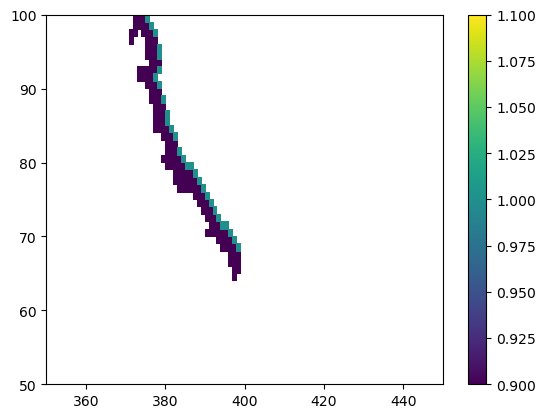

In [137]:
plt.pcolor(xr.where(mask_basin == True, mask_basin, np.nan))
plt.pcolor(xr.where(mask_TS_basin == True, mask_TS_basin, np.nan))
plt.colorbar()
plt.xlim(350,450)
plt.ylim(50,100)

In [139]:
# Create arrays for the data to be propagated to
T_of_interest = np.ndarray(len(depths_of_interest))
S_of_interest = np.ndarray(len(depths_of_interest))
# propagate the data to these arrays 
for jj in range(len(depths_of_interest)):
    T_of_interest[jj] = T_profile.sel(deptht = depths_of_interest[jj], method = 'nearest')
    S_of_interest[jj] = S_profile.sel(deptht = depths_of_interest[jj], method = 'nearest')
T_prop[mask_basin] = T_of_interest
S_prop[mask_basin] = S_of_interest

In [96]:
kk = 2
i = basin_nos[kk]
# Extract the closed cavity points which are in that basin
mask_basin = basins_NEMO*masks.closed_cavities_nan == i
x_b, y_b = transformer.transform(so.nav_lat_grid_T.data[mask_basin], so.nav_lon_grid_T.data[mask_basin])
points_basin = np.array(list(zip(x_b,y_b)))
# Query the cKDTree to calculate the distances to points within the basin
distance, index = tree.query(points_basin)
# Extract only the points that are adjacent to the closed cavity (by using the minimum distance) 
results = tree.query_ball_point(points_basin, r = np.min(distance)*np.sqrt(2))
# Extract indexes and create a list of the unique points adjacent to the closed cavity 
merged = np.unique(list(itertools.chain.from_iterable(results)))
chosen_x = OC_x[merged]
chosen_y = OC_y[merged]
chosen_x, chosen_y
points_chosen = np.array(list(zip(chosen_x, chosen_y)))
# Create a cKD Tree with the chosen points 
tree_i = cKDTree(points_chosen)
# Query the tree for the points within the closed cavity
distance, index = tree_i.query(points_basin)
distances_OC[mask_basin] = distance
chosen_lon = so.nav_lon_grid_T.data[ocean_open_cavities == 1][merged]
chosen_lat = so.nav_lat_grid_T.data[ocean_open_cavities == 1][merged]
# Calculate the average direction to the edge of the closed ice shelf cavity 
#x_mdiff = np.mean(chosen_lon) - np.mean(gridT2.nav_lon.data[mask_basin])
#y_mdiff = np.mean(chosen_lat) - np.mean(gridT2.nav_lat.data[mask_basin])
#direction = np.arctan2(y_mdiff, x_mdiff)
#direction_to_front[mask_basin] = np.ones(len(points_basin)) * direction
# Create a mask of the chosen points along the front of the cavity 
a = xr.where(so.nav_lon_grid_T == 200,0,0)
for j in range(len(chosen_lon)):
    a =a + xr.where((so.nav_lat_grid_T == chosen_lat[j]) & (so.nav_lon_grid_T == chosen_lon[j]),1, 0).data
# Use this mask to select the points of interest and then take the mean for each depth 
T_profiles[kk] = thetao_time.where(a == 1).mean(dim = ['x_grid_T','y_grid_T'])
S_profiles[kk] = so_time.where(a == 1).mean(dim = ['x_grid_T','y_grid_T'])
# Calculate the depth of the ice-ocean interface 
depths_of_interest = (positive*thetao_time.deptht).sum(dim = 'deptht').data[mask_basin]
T_profile = T_profiles[kk]
S_profile = S_profiles[kk]
# Set the T and S profiles so that they have values at all depths from the top and bottom of the bit with values 
mask = T_profile > -20 # 
# Calculate max and min ocean profile depths and associated temperatures 
max_profile_depth = np.max(T_profile.deptht[mask].data)
max_profile_depth_T = T_profile.sel(deptht = max_profile_depth)
max_profile_depth_S = S_profile.sel(deptht = max_profile_depth)
min_profile_depth = np.min(T_profile.deptht[mask].data)
min_profile_depth_T = T_profile.sel(deptht = min_profile_depth)
min_profile_depth_S = S_profile.sel(deptht = min_profile_depth)
mask_top = (T_profile.deptht <= min_profile_depth)
mask_bottom = (T_profile.deptht > max_profile_depth)
# Propagate the profiles with these values 
T_profile_np = T_profile.data
T_profile_np[mask_top] = min_profile_depth_T
T_profile_np[mask_bottom] = max_profile_depth_T
S_profile_np = S_profile.data
S_profile_np[mask_top] = min_profile_depth_S
S_profile_np[mask_bottom] = max_profile_depth_S
# Create arrays for the data to be propagated to
T_of_interest = np.ndarray(len(depths_of_interest))
S_of_interest = np.ndarray(len(depths_of_interest))
# propagate the data to these arrays 
for jj in range(len(depths_of_interest)):
    T_of_interest[jj] = T_profile.sel(deptht = depths_of_interest[jj], method = 'nearest')
    S_of_interest[jj] = S_profile.sel(deptht = depths_of_interest[jj], method = 'nearest')
T_prop[mask_basin] = T_of_interest
S_prop[mask_basin] = S_of_interest
if verbose == 2:
    print('Creating and propagating profiles:', kk+1, 'out of', len(basin_nos), 'processed', end = '\r')
if verbose == 1:
    print('Currently processing:', year, month, ',', \
          kk+1, 'out of', len(basin_nos), 'profiles processed', end = '\r')

In [83]:
masks = xr.open_dataset(filepath_mask)
ocean_open_cavities = masks.ocean_open_cavities.data
grounded_ice = masks.grounded_ice.data
ocean_only = masks.ocean_only.data
closed_cavities = masks.closed_cavities.data
masks.close()
basins_NEMO = basins_merged
# Calculate the basin numbers of any basin which contains closed cavities 
basin_nos_temp = np.unique(basins_NEMO)
count = np.zeros(len(basin_nos_temp))
for i in range(len(basin_nos_temp)):
    count[i] = np.sum((basins_NEMO*masks.closed_cavities_nan) == basin_nos_temp[i])
mask_keep_nos = count != 0
basin_nos = basin_nos_temp[mask_keep_nos]
# Calculate depth of ocean interface
mask_temp_values = xr.where(thetao_time > -200, 1,0)
mask_diff_temp = (mask_temp_values - mask_temp_values.shift(deptht=1))
positive = xr.where(mask_diff_temp == 1, 1, np.nan)
negative = xr.where(mask_diff_temp == -1, 1, np.nan)
# Create empty arrays for the propagated temperature and salinity (on NEMO grid)
T_prop = np.ones(so.nav_lat_grid_T.data.shape)*np.nan
S_prop = np.ones(so.nav_lat_grid_T.data.shape)*np.nan
# Create arrays for the temperature and salinity profiles
T_profiles = np.ndarray(len(basin_nos), dtype = np.ndarray) 
S_profiles = np.ndarray(len(basin_nos), dtype = np.ndarray) 
for kk in range(len(basin_nos)):
#for kk in (1,31):
    i = basin_nos[kk]
    # Extract the closed cavity points which are in that basin
    mask_basin = basins_NEMO*masks.closed_cavities_nan == i
    x_b, y_b = transformer.transform(so.nav_lat_grid_T.data[mask_basin], so.nav_lon_grid_T.data[mask_basin])
    points_basin = np.array(list(zip(x_b,y_b)))
    # Query the cKDTree to calculate the distances to points within the basin
    distance, index = tree.query(points_basin)
    # Extract only the points that are adjacent to the closed cavity (by using the minimum distance) 
    results = tree.query_ball_point(points_basin, r = np.min(distance)*np.sqrt(2))
    # Extract indexes and create a list of the unique points adjacent to the closed cavity 
    merged = np.unique(list(itertools.chain.from_iterable(results)))
    chosen_x = OC_x[merged]
    chosen_y = OC_y[merged]
    chosen_x, chosen_y
    points_chosen = np.array(list(zip(chosen_x, chosen_y)))
    # Create a cKD Tree with the chosen points 
    tree_i = cKDTree(points_chosen)
    # Query the tree for the points within the closed cavity
    distance, index = tree_i.query(points_basin)
    distances_OC[mask_basin] = distance
    chosen_lon = so.nav_lon_grid_T.data[ocean_open_cavities == 1][merged]
    chosen_lat = so.nav_lat_grid_T.data[ocean_open_cavities == 1][merged]
    # Calculate the average direction to the edge of the closed ice shelf cavity 
    #x_mdiff = np.mean(chosen_lon) - np.mean(gridT2.nav_lon.data[mask_basin])
    #y_mdiff = np.mean(chosen_lat) - np.mean(gridT2.nav_lat.data[mask_basin])
    #direction = np.arctan2(y_mdiff, x_mdiff)
    #direction_to_front[mask_basin] = np.ones(len(points_basin)) * direction
    # Create a mask of the chosen points along the front of the cavity 
    a = xr.where(so.nav_lon_grid_T == 200,0,0)
    for j in range(len(chosen_lon)):
        a =a + xr.where((so.nav_lat_grid_T == chosen_lat[j]) & (so.nav_lon_grid_T == chosen_lon[j]),1, 0).data
    # Use this mask to select the points of interest and then take the mean for each depth 
    T_profiles[kk] = thetao_time.where(a == 1).mean(dim = ['x_grid_T','y_grid_T'])
    S_profiles[kk] = so_time.where(a == 1).mean(dim = ['x_grid_T','y_grid_T'])
    # Calculate the depth of the ice-ocean interface 
    depths_of_interest = (positive*thetao_time.deptht).sum(dim = 'deptht').data[mask_basin]
    T_profile = T_profiles[kk]
    S_profile = S_profiles[kk]
    # Set the T and S profiles so that they have values at all depths from the top and bottom of the bit with values 
    mask = T_profile > -20 # 
    # Calculate max and min ocean profile depths and associated temperatures 
    max_profile_depth = np.max(T_profile.deptht[mask].data)
    max_profile_depth_T = T_profile.sel(deptht = max_profile_depth)
    max_profile_depth_S = S_profile.sel(deptht = max_profile_depth)
    min_profile_depth = np.min(T_profile.deptht[mask].data)
    min_profile_depth_T = T_profile.sel(deptht = min_profile_depth)
    min_profile_depth_S = S_profile.sel(deptht = min_profile_depth)
    mask_top = (T_profile.deptht <= min_profile_depth)
    mask_bottom = (T_profile.deptht > max_profile_depth)
    # Propagate the profiles with these values 
    T_profile_np = T_profile.data
    T_profile_np[mask_top] = min_profile_depth_T
    T_profile_np[mask_bottom] = max_profile_depth_T
    S_profile_np = S_profile.data
    S_profile_np[mask_top] = min_profile_depth_S
    S_profile_np[mask_bottom] = max_profile_depth_S
    # Create arrays for the data to be propagated to
    T_of_interest = np.ndarray(len(depths_of_interest))
    S_of_interest = np.ndarray(len(depths_of_interest))
    # propagate the data to these arrays 
    for jj in range(len(depths_of_interest)):
        T_of_interest[jj] = T_profile.sel(deptht = depths_of_interest[jj], method = 'nearest')
        S_of_interest[jj] = S_profile.sel(deptht = depths_of_interest[jj], method = 'nearest')
    T_prop[mask_basin] = T_of_interest
    S_prop[mask_basin] = S_of_interest
    if verbose == 2:
        print('Creating and propagating profiles:', kk+1, 'out of', len(basin_nos), 'processed', end = '\r')
    if verbose == 1:
        print('Currently processing:', year, month, ',', \
              kk+1, 'out of', len(basin_nos), 'profiles processed', end = '\r')

/tmp/ipykernel_1841208/1059913632.py:2: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


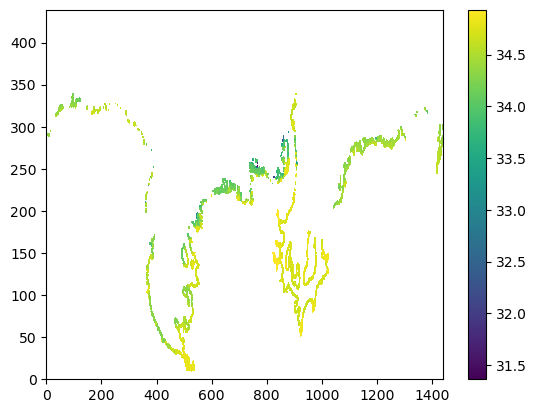

In [87]:
plt.pcolor(S_prop)
plt.colorbar()

In [66]:
mask_top

<xarray.DataArray 'deptht' (deptht: 121)>
array([ True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False])
Coordinates:
  * deptht   (deptht) float32 0.4921 1.526 2.638 ... 5.698e+03 5.902e+03

In [65]:
T_profile

<xarray.DataArray 'thetao' (deptht: 121)>
array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        , -0.1340797 , -1.2831392 , -1.9506522 , -2.4128416 ,
       -2.4492714 , -2.3882954 , -2.3192468 , -2.241916  , -2.1752229 ,
       -2.1050787 , -2.0533416 , -1.8036157 , -1.407552  , -1.2389998 ,
       -1.073826  , -0.4829495 , -0.16074732,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ], dtype=float32)
Coordinates:
  * deptht   (deptht) float32 0.4921 1.526 2.638 ... 5.698e+03 5.902e+03

/tmp/ipykernel_1077965/832108437.py:3: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


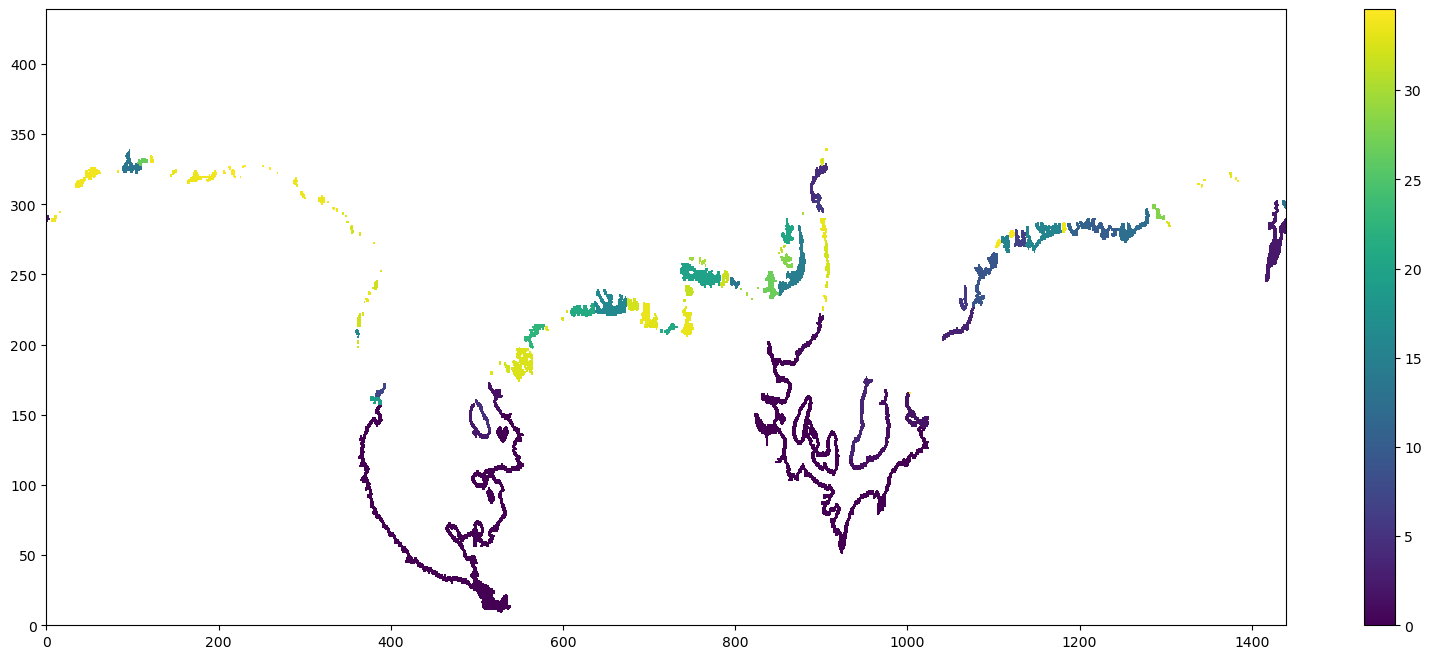

In [58]:
fig, ax = plt.subplots(1,1, figsize = (20,8))
plt.pcolor(S_prop)
plt.colorbar()

In [ ]:
ds = xr.Dataset(
                data_vars=dict(
                    temperature_prop    = (["y", "x"], T_prop),
                    salinity_prop       = (["y", "x"], S_prop),
                    melt_ice_per_yr     = (["y", "x"], (fwfisf_time.values*masks.closed_cavities_nan).data),
                    ),
                coords=dict(
                    lon=(("y", "x"), interp_S.lon.data),
                    lat=(("y", "x"), interp_S.lat.data),    ),
                attrs=dict(description = "Pointwise T, S, and melt", 
                           simulation_run = 'Christoph_CFG',
                           year = year,
                           month = month)
                    )
#fp_TSmelt = filepaths_TSmelt + '_y' + str(year) + '_m' + str(month).zfill(2) +'.nc'
#ds.to_netcdf(fp_TSmelt)
ds.to_netcdf(filepath_nn_input + nemo_run + '_' + str(year_of_interest) + '_' + month_of_interest + '.nc')
print('You have saved the following file')
print(fp_TSmelt)

In [69]:
import sys

In [71]:
print('Welcome')
nemo_run = 'OPM031'
verify_if_already_run = False

# Set all the filepaths that will be required 
filepath_data_ho = "/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/"
filepath_masks = filepath_data_ho + "masks_"
filepath_nico_on_nemo = filepath_data_ho + "nico_on_nemo_"
filepath_nn_input = filepath_data_ho + "nn_input_"
filepath_distances = filepath_data_ho + "grid_distances.nc" 

if nemo_run == 'OPM031':
    filepath_pierre = '/bettik/mathiotp/NEMO/DRAKKAR/eORCA025.L121/eORCA025.L121-OPM031/eORCA025.L121-OPM031-S/1m/'
    file_extension = '*/*gridT.nc'

Welcome


In [81]:
glob.glob(filepath_nn_input + nemo_run + '_' + str(year) +'*.nc') 

['/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_input_OPM031_2025_05.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_input_OPM031_2025_07.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_input_OPM031_2025_09.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_input_OPM031_2025_02.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_input_OPM031_2025_01.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_input_OPM031_2025_06.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_input_OPM031_2025_11.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_input_OPM031_2025_03.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_input_OPM031_2025_04.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_input_OPM031_2025_10.nc',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/dat

In [84]:
data = xr.open_dataset(filepath_nn_input + nemo_run + '_' + str(year_of_interest) + '_' + '01' + '.nc')

/tmp/ipykernel_1077965/2222258133.py:4: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


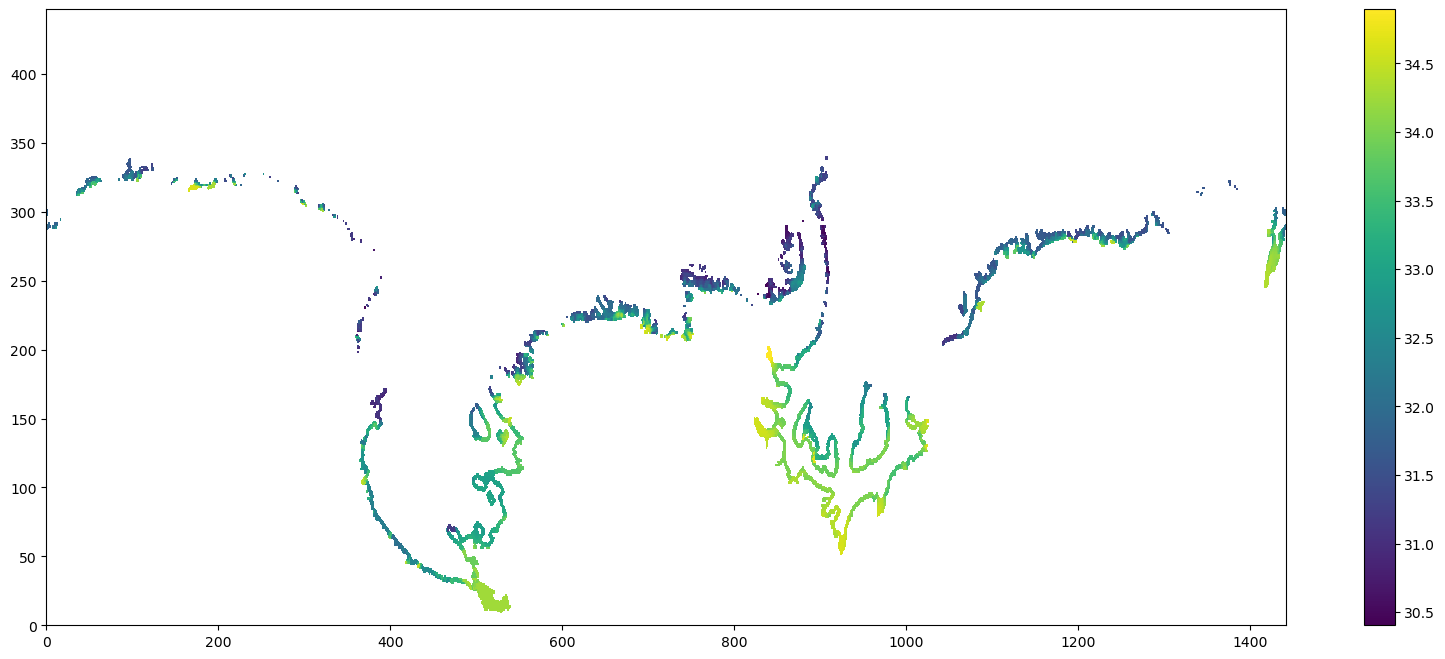

In [94]:
data = xr.open_dataset(filepath_nn_input + nemo_run + '_' + str(year_of_interest) + '_' + '01' + '.nc')
fig, ax = plt.subplots(1,1, figsize = (20,8))
plt.pcolor(data.salinity_prop.data)
plt.colorbar()

In [23]:
filepaths_TSmelt = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Christoph/TSmelt_v2'

/tmp/ipykernel_2362462/1910037086.py:7: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


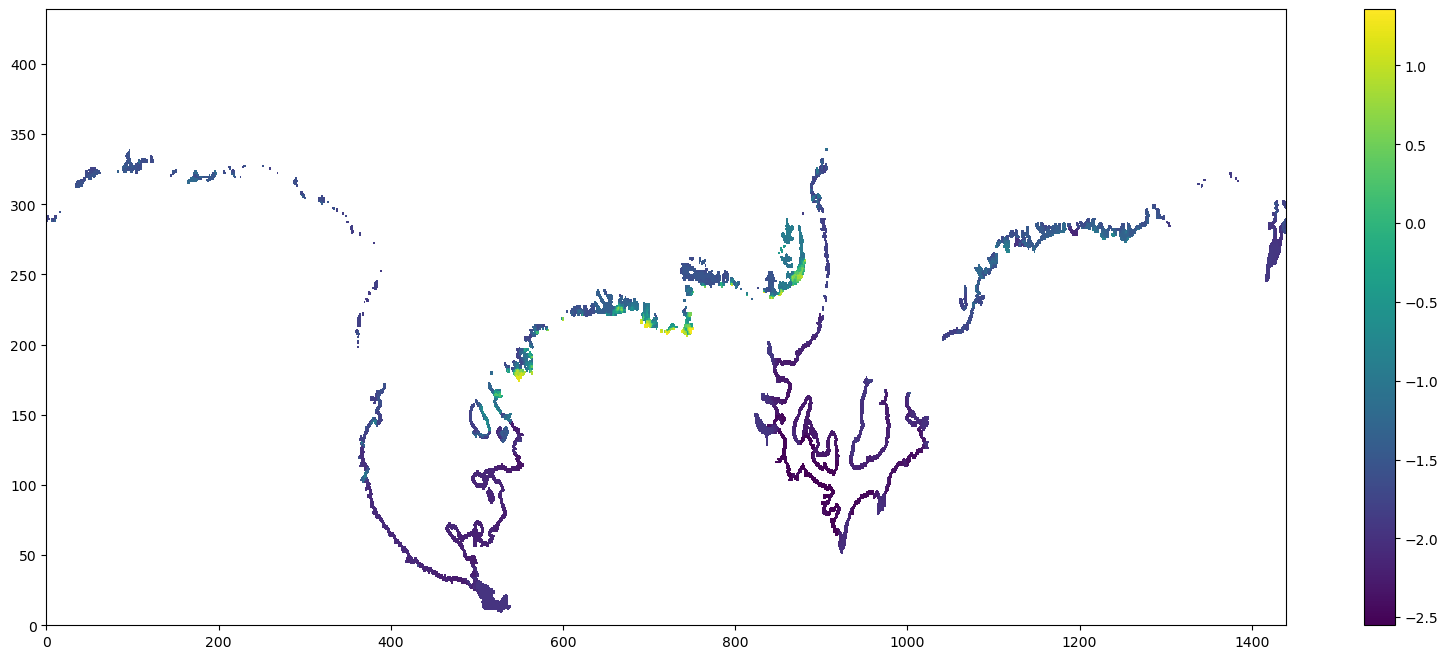

In [25]:
year = 2044 
month = 4
data = xr.open_dataset(filepaths_TSmelt + '_y' + str(year) + '_m' + str(month).zfill(2) +'.nc')
fig, ax = plt.subplots(1,1, figsize = (20,8))
#plt.pcolor((data.salinity_prop.data- np.nanmin(data.salinity_prop.data))*8.4)
plt.pcolor(data.temperature_prop.data)
plt.colorbar()

In [77]:
year_of_interest = str(year)
month_of_interest = str(month)

start_time = time.time()
T_here, S_here = extract_useful_variables_monthly(nemo_run, year_of_interest, month_of_interest, filepath_pierre, \
                                     filepath_masks, filepath_distances, filepath_nn_input, verbose = 2)

FileNotFoundError: [Errno 2] No such file or directory: b'/bettik/mathiotp/NEMO/DRAKKAR/eORCA025.L121/eORCA025.L121-OPM031/eORCA025.L121-OPM031-S/1m/2025/eORCA025.L121-OPM031_y2025m0.1m_gridT.nc'